# Muhammad Haissam

## Week 1: Exploratory Data Analysis
### Project 1: ML-Powered Customer Analytics

**University:** Quaid-i-Azam University, Islamabad
**Department:** Electronics
**Date:** 4 October 2026

**Dataset:** Telco Customer Churn

**Objective:** Explore customer characteristics, services, and billing
information to identify patterns associated with customer churn.

**Customer churn** means a customer leaving or cancelling a company's service.

In [21]:
# Tools for working with data
import pandas as pd
import numpy as np

# Tools for drawing graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Default appearance of our graphs
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Dataset Overview

In [22]:
# Location of the CSV file attached to this notebook
dataset_path = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Read the CSV into a Pandas table
df = pd.read_csv(dataset_path)

# Show the number of rows and columns
print("Dataset shape (rows, columns):", df.shape)

# Display the first five rows
df.head()

Dataset shape (rows, columns): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.1 Column Information

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 1.2 Data Quality and Missing Values

In [24]:
# Convert text charges into numbers
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

# Count missing values in each column
missing = df.isna().sum()

print("Columns with missing values:")
print(missing[missing > 0])

print("\nRows with missing TotalCharges:")
display(
    df.loc[
        df["TotalCharges"].isna(),
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
    ]
)

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Columns with missing values:
TotalCharges    11
dtype: int64

Rows with missing TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN



Duplicate rows: 0
Duplicate customer IDs: 0


### 1.3 Numerical Summary

In [25]:
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7032.00
mean,0.16,32.37,64.76,2283.30
std,0.37,24.56,30.09,2266.77
min,0.00,0.00,18.25,18.80
25%,0.00,9.00,35.50,401.45
50%,0.00,29.00,70.35,1397.48
75%,0.00,55.00,89.85,3794.74
max,1.00,72.00,118.75,8684.80


### 1.4 Churn Distribution

In [26]:
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    "Customers": churn_counts,
    "Percentage": churn_percentages.round(2)
})

display(churn_summary)

,Customers,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


### Dataset Overview — Findings

The dataset contains 7,043 customer records and 21 columns covering customer details, services, and billing. Of these customers, 1,869 churned (26.54%), while 5,174 stayed (73.46%). The two groups are unequal in size, which will matter when evaluating prediction models in Week 2.

TotalCharges was initially stored as text. Converting it to numbers revealed 11 missing values, all belonging to customers with zero months of tenure. I kept these values missing during exploration and excluded those rows only from analyses requiring TotalCharges. There were no duplicate rows or duplicate customer IDs.

## 2. Numerical Features Analysis

### 2.1 Customer Tenure

Tenure is the number of months a customer has stayed with the company.

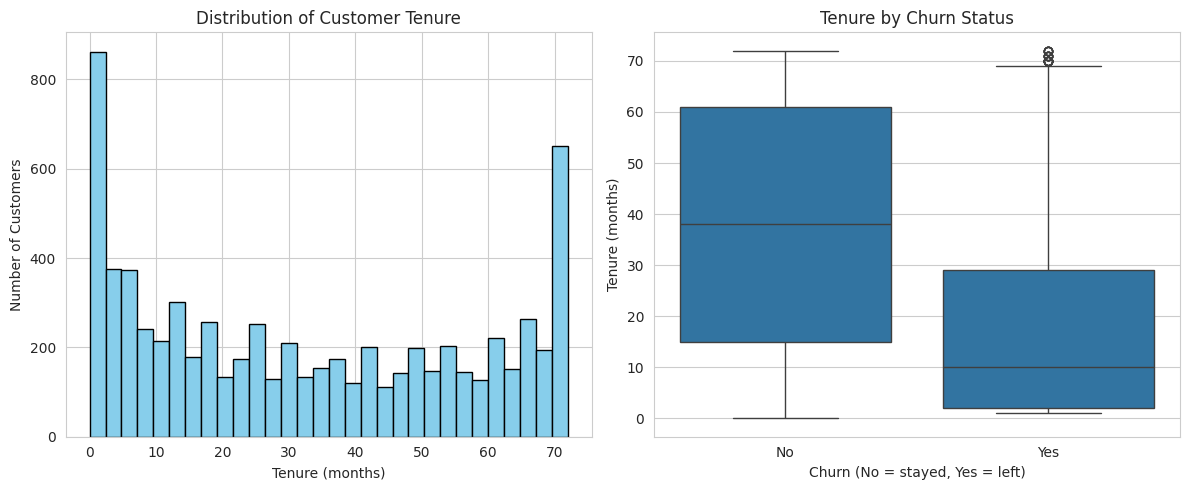

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution of tenure across all customers
axes[0].hist(
    df["tenure"],
    bins=30,
    color="skyblue",
    edgecolor="black"
)
axes[0].set_title("Distribution of Customer Tenure")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Number of Customers")

# Compare tenure between customers who stayed and churned
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    order=["No", "Yes"],
    ax=axes[1]
)
axes[1].set_title("Tenure by Churn Status")
axes[1].set_xlabel("Churn (No = stayed, Yes = left)")
axes[1].set_ylabel("Tenure (months)")

plt.tight_layout()
plt.show()

### Tenure — Findings

Customers who churned had a median tenure of 10 months, compared with 38 months for customers who stayed. The histogram also shows concentrations of customers near the beginning and end of the tenure range.

Shorter tenure is associated with churn in this dataset. This makes tenure a useful feature to investigate when building the prediction models.

### 2.2 Monthly Charges

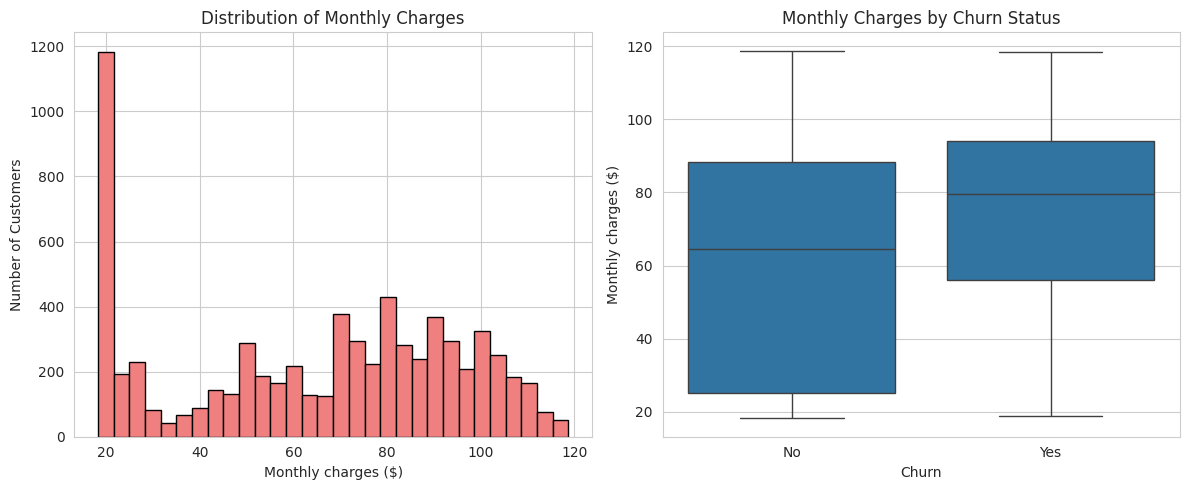

,count,mean,median
Churn,,,
No,5174,61.27,64.43
Yes,1869,74.44,79.65


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    df["MonthlyCharges"],
    bins=30,
    color="lightcoral",
    edgecolor="black"
)
axes[0].set_title("Distribution of Monthly Charges")
axes[0].set_xlabel("Monthly charges ($)")
axes[0].set_ylabel("Number of Customers")

sns.boxplot(
    data=df, x="Churn", y="MonthlyCharges",
    order=["No", "Yes"], ax=axes[1]
)
axes[1].set_title("Monthly Charges by Churn Status")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly charges ($)")

plt.tight_layout()
plt.show()

display(
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median"])
    .round(2)
)

### Monthly Charges — Findings

The median monthly charge was $79.65 for customers who churned and $64.43 for those who stayed. The average charges followed the same pattern: $74.44 and $61.27, respectively.

Customers who churned generally had higher monthly bills. However, this comparison does not show whether price itself caused them to leave. Service type and contract terms may also be related to the difference.

### 2.3 Total Charges

Rows with missing TotalCharges are excluded only from this analysis.
The original customer table is retained.

Customers included: 7032
Customers excluded: 11


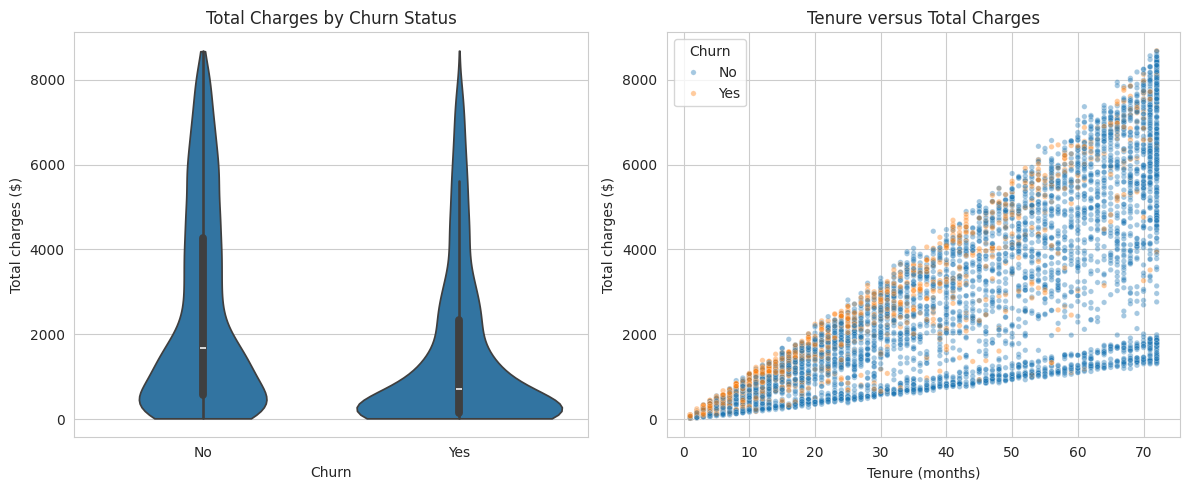

,mean,median
Churn,,
No,2555.34,1683.60
Yes,1531.80,703.55


In [29]:
df_clean = df[df["TotalCharges"].notna()].copy()

print("Customers included:", len(df_clean))
print("Customers excluded:", len(df) - len(df_clean))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(
    data=df_clean, x="Churn", y="TotalCharges",
    order=["No", "Yes"], cut=0, ax=axes[0]
)
axes[0].set_title("Total Charges by Churn Status")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Total charges ($)")

sns.scatterplot(
    data=df_clean,
    x="tenure",
    y="TotalCharges",
    hue="Churn",
    alpha=0.4,
    s=15,
    ax=axes[1]
)
axes[1].set_title("Tenure versus Total Charges")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Total charges ($)")

plt.tight_layout()
plt.show()

display(
    df_clean.groupby("Churn")["TotalCharges"]
    .agg(["mean", "median"])
    .round(2)
)

### Total Charges — Findings

This analysis includes 7,032 customers with recorded total charges. The 11 customers with missing values remain in the main dataset.

Customers who stayed had median total charges of $1,683.60, compared with $703.55 for customers who churned. The scatter plot shows that total charges generally increase with tenure. This helps explain why customers who stayed accumulated larger bills: they usually remained with the company longer.

## 3. Categorical Features Analysis

### 3.1 Contract Type

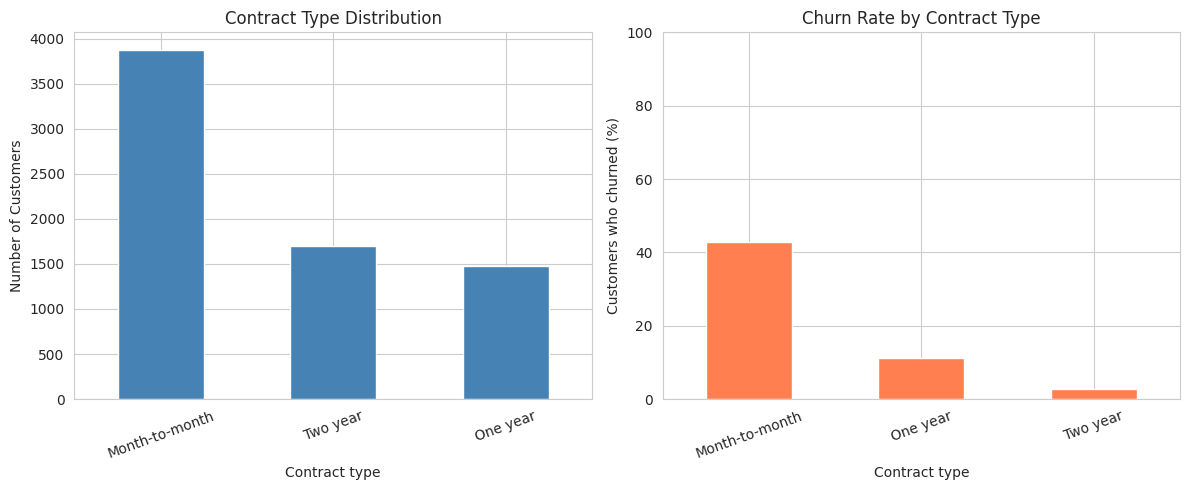

Churn,Churn rate (%)
Contract,
Month-to-month,42.71
One year,11.27
Two year,2.83


In [30]:
contract_counts = df["Contract"].value_counts()

contract_rates = pd.crosstab(
    df["Contract"], df["Churn"], normalize="index"
) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

contract_counts.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Contract Type Distribution")
axes[0].set_xlabel("Contract type")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=20)

contract_rates["Yes"].plot.bar(ax=axes[1], color="coral")
axes[1].set_title("Churn Rate by Contract Type")
axes[1].set_xlabel("Contract type")
axes[1].set_ylabel("Customers who churned (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(
    contract_rates[["Yes"]]
    .rename(columns={"Yes": "Churn rate (%)"})
    .round(2)
)

### Contract Type — Findings

Month-to-month customers had a churn rate of 42.71%. This was much higher than the rates for one-year contracts (11.27%) and two-year contracts (2.83%).

Contract type shows a clear association with churn. Month-to-month customers appear to be an important group for retention analysis, although these results alone do not prove that switching someone to a longer contract would prevent them from leaving.

### 3.2 Internet Service

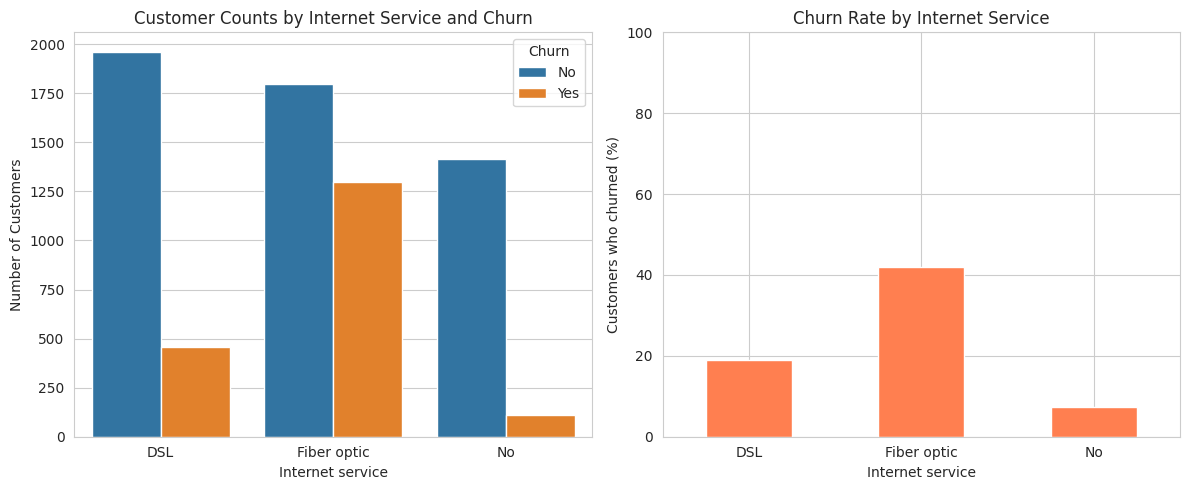

Churn,Churn rate (%)
InternetService,
DSL,18.96
Fiber optic,41.89
No,7.40


In [31]:
internet_rates = pd.crosstab(
    df["InternetService"], df["Churn"], normalize="index"
) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    hue_order=["No", "Yes"],
    ax=axes[0]
)
axes[0].set_title("Customer Counts by Internet Service and Churn")
axes[0].set_xlabel("Internet service")
axes[0].set_ylabel("Number of Customers")

internet_rates["Yes"].plot.bar(ax=axes[1], color="coral")
axes[1].set_title("Churn Rate by Internet Service")
axes[1].set_xlabel("Internet service")
axes[1].set_ylabel("Customers who churned (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

display(
    internet_rates[["Yes"]]
    .rename(columns={"Yes": "Churn rate (%)"})
    .round(2)
)

### Internet Service — Findings

Fiber optic customers had the highest churn rate at 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service.

The difference makes internet service type worth investigating further. It does not tell us why fiber optic customers left. Comparing their monthly charges, tenure, and contract types could help explain the pattern.

### 3.3 Payment Method

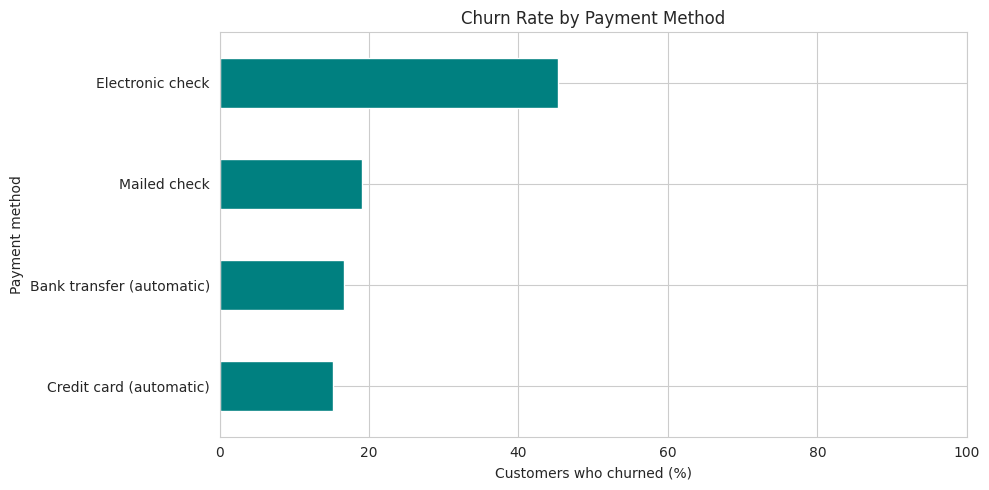

Churn,Churn rate (%)
PaymentMethod,
Electronic check,45.29
Mailed check,19.11
Bank transfer (automatic),16.71
Credit card (automatic),15.24


In [32]:
payment_rates = pd.crosstab(
    df["PaymentMethod"], df["Churn"], normalize="index"
) * 100

payment_rates["Yes"].sort_values().plot.barh(
    figsize=(10, 5),
    color="teal"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Customers who churned (%)")
plt.ylabel("Payment method")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

display(
    payment_rates[["Yes"]]
    .rename(columns={"Yes": "Churn rate (%)"})
    .sort_values("Churn rate (%)", ascending=False)
    .round(2)
)

### Payment Method — Findings

Electronic check customers had the highest churn rate at 45.29%. The rates were lower for mailed checks (19.11%), automatic bank transfers (16.71%), and automatic credit card payments (15.24%).

Payment method is associated with churn, but other customer characteristics could explain part of this difference. Electronic check users are a group worth examining more closely in the next stage.

## 4. Correlation Analysis

Selected Yes/No fields are encoded as 1/0 in a separate copy
of the dataset for correlation analysis.

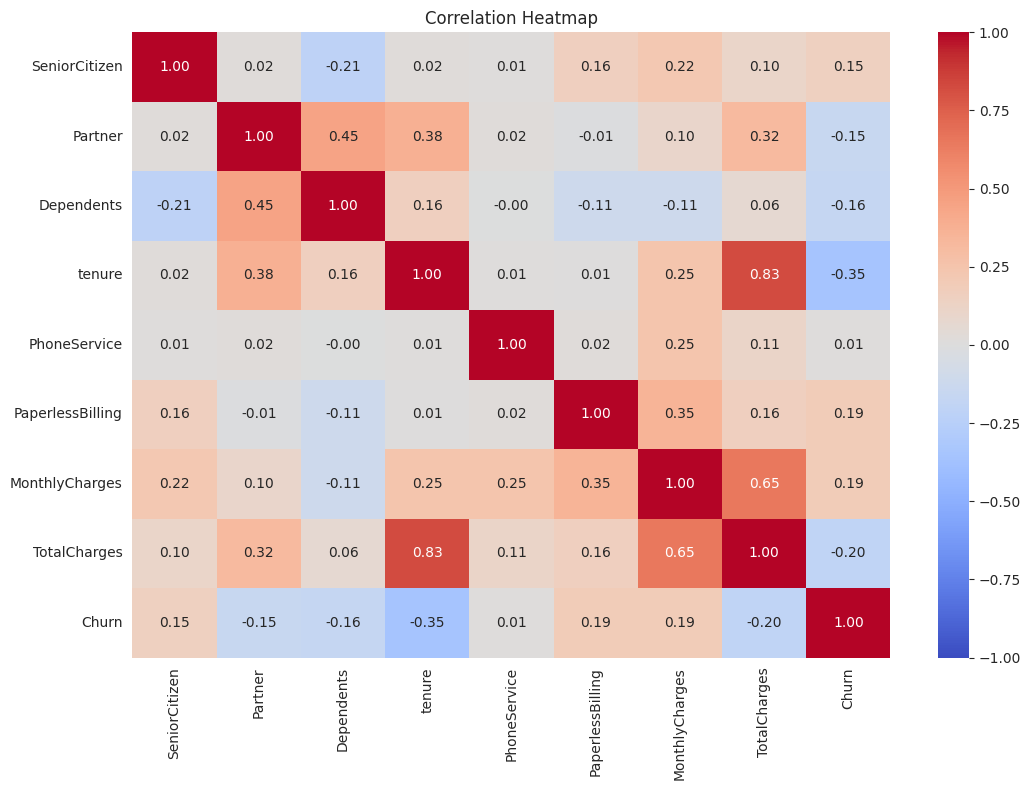

Correlations with churn:


tenure             -0.352
TotalCharges       -0.199
Dependents         -0.164
Partner            -0.150
PhoneService        0.012
SeniorCitizen       0.151
PaperlessBilling    0.192
MonthlyCharges      0.193
Name: Churn, dtype: float64

In [33]:
df_numeric = df.copy()

binary_columns = [
    "Churn",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for column in binary_columns:
    df_numeric[column] = df_numeric[column].map({
        "Yes": 1,
        "No": 0
    })

numeric_features = df_numeric.select_dtypes(include=[np.number])
correlations = numeric_features.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlations with churn:")
display(
    correlations["Churn"]
    .drop("Churn")
    .sort_values()
    .round(3)
)

### Correlation — Findings

Among the fields included in the heatmap, tenure had the strongest negative correlation with churn at -0.352. This agrees with the earlier comparison showing shorter tenure among customers who left.

MonthlyCharges had the largest positive correlation with churn among the displayed fields at 0.193, closely followed by PaperlessBilling at 0.192. TotalCharges had a negative correlation of -0.199. These are associations, and some fields are related to each other, so they should not be interpreted as independent causes of churn.

In [34]:
print("Dataset size:", df.shape)
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

display(churn_summary)

print("Tenure by churn status:")
display(
    df.groupby("Churn")["tenure"]
    .agg(["mean", "median"])
    .round(2)
)

Dataset size: (7043, 21)
Missing TotalCharges: 11
Duplicate rows: 0
Duplicate customer IDs: 0


,Customers,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


Tenure by churn status:


,mean,median
Churn,,
No,37.57,38.0
Yes,17.98,10.0


## 5. Key Findings and Next Steps

The overall churn rate was 26.54%. Several patterns stood out during the analysis:

- Customers who churned had shorter median tenure: 10 months versus 38 months.
- Their median monthly charges were higher: $79.65 versus $64.43.
- Month-to-month contracts had a churn rate of 42.71%, compared with 2.83% for two-year contracts.
- Fiber optic customers had a churn rate of 41.89%.
- Electronic check users had the highest payment-method churn rate at 45.29%.

These patterns suggest that tenure, monthly charges, contract type, internet service, and payment method are useful starting features for Week 2. Each comparison looks at a characteristic separately; it does not establish which combination produces the highest risk.

The analysis describes patterns in this dataset. It does not establish the reasons customers left or guarantee that the same relationships will hold for another company.

### Questions for Week 2

1. How well can these features predict churn for customers the model has not seen during training?
2. How much do internet service and payment method contribute to prediction when tenure, charges, and contract type are also included?